In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, log_loss
from imblearn.over_sampling import ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import VotingClassifier

# 1. Cost-Sensitive Wrapper for XGBoost
class CostSensitiveXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

# 2. Logistic Regression Tuning Function
# def lr_train(X, y, cw=None):
#     kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     C_values = np.logspace(-2, 2, 10)
#     grid = GridSearchCV(
#         LogisticRegression(random_state=42, max_iter=1000, class_weight=cw),
#         {'C': C_values},
#         cv=kf,
#         scoring='accuracy',
#         n_jobs=4,
#         verbose=1
#     )
#     grid.fit(X, y)
#     print(f"\nBest LR CV accuracy: {grid.best_score_:.4f}")
#     print("Best C:", grid.best_params_['C'])
#     return grid.best_estimator_

# 3. Load & Split Data
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# 4. Define Oversampling + Model Pipelines

# 4a. ADASYN + Logistic Regression
pipe_lr = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lr', LogisticRegression(penalty='l2',C=0.215,solver='lbfgs', class_weight='balanced', max_iter=2000, random_state=42))
])

# 4b. BorderlineSMOTE + SVM
pipe_svm = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('svm', SVC(C=100,class_weight='balanced', probability=True, random_state=42))
])

# 4c. ADASYN + LightGBM
pipe_lgbm = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lgbm', LGBMClassifier(lambda_l1=1.0,lambda_l2=1.0,learning_rate=0.05,n_estimators=200,class_weight='balanced',random_state=42))
])
# pipe_lgbm.set_params(
#     lgbm__early_stopping_rounds=50,
#     lgbm__eval_set=[(X_val, y_val)]
# )

# 4d. BorderlineSMOTE + Cost-Sensitive XGBoost
pipe_xgb = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('xgb', CostSensitiveXGBClassifier(
        learning_rate=0.1,
        n_estimators=100,
        reg_alpha=0.1, 
        reg_lambda=1.0,
        objective='multi:softprob',
        num_class=num_classes,
        eval_metric='mlogloss',
        random_state=42
    ))
])

pipe_xgb.set_params(
  xgb__early_stopping_rounds=50,
  xgb__eval_set=[(X_val, y_val)]
)


# # 5. Tune Logistic Regression (not in pipeline)
# best_lr = lr_train(X_train, y_train, cw='balanced')

# 6. Ensemble Voting (replace RF with SVM)
ensemble = VotingClassifier(
    estimators=[
        ('lr_best',pipe_lr),
        ('svm', pipe_svm),
        ('lgbm', pipe_lgbm),
        ('xgb', pipe_xgb)
    ],
    voting='soft'
)

# 7. Train Ensemble
ensemble.fit(X_train, y_train)

# 8. Evaluate on Validation Set
y_pred = ensemble.predict(X_val)
y_proba = ensemble.predict_proba(X_val)

print("Ensemble Validation Accuracy:", accuracy_score(y_val, y_pred))
print("Ensemble Classification Report:")
print(classification_report(y_val, y_pred, zero_division=0))




Number of classes: 28
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.068581 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 98038, number of used features: 300
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[Li

In [2]:
import numpy as np

def weighted_log_loss_formula(y_true, y_pred_proba, eps=1e-15):
    """
    按照公式 L = - ∑_i w_{y_i} * log(p̂_i)，w_y = 1 / f_y，
    最后除以 N 得到 average per sample。
    y_true: array-like (N,)  真实标签 0…C-1
    y_pred_proba: array (N, C)  模型预测的各类概率
    """
    y_true = np.asarray(y_true)
    N, C = y_pred_proba.shape

    # 1) 计算每个类别的频次 f_y
    class_counts = np.bincount(y_true, minlength=C)
    # 如果某类在这一集合里完全没出现，就把它当 1 处理，避免除零
    class_counts[class_counts == 0] = 1

    # 2) w_y = 1 / f_y
    class_weights = 1.0 / class_counts

    # 3) 提取每个样本的 p̂_i = P(y_true[i])
    p = y_pred_proba[np.arange(N), y_true]
    p = np.clip(p, eps, 1 - eps)  # 避免 log(0)

    # 4) 计算加权 log‐loss
    losses = - class_weights[y_true] * np.log(p)

    # 5) 返回平均 per sample
    return losses.sum() / N

# —— 一次性算 train & val loss —— 
y_train_proba = ensemble.predict_proba(X_train)
y_val_proba   = ensemble.predict_proba(X_val)

train_wll = weighted_log_loss_formula(y_train, y_train_proba)
val_wll   = weighted_log_loss_formula(y_val,   y_val_proba)

print(f"Training weighted log‐loss:   {train_wll:.4f}")
print(f"Validation weighted log‐loss: {val_wll:.4f}")


[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
Training weighted log‐loss:   0.0002
Validation weighted log‐loss: 0.0347


[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0


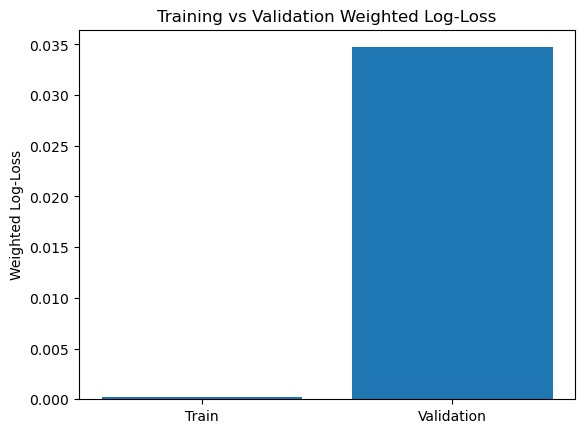

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, log_loss
from sklearn.utils.class_weight import compute_sample_weight

# ----------------------------
# 1. Weighted log-loss formula
# ----------------------------
def weighted_log_loss(y_true, y_pred_proba, eps=1e-15):
    y_true = np.asarray(y_true)
    N, C = y_pred_proba.shape
    class_counts = np.bincount(y_true, minlength=C)
    class_counts[class_counts == 0] = 1
    class_weights = 1.0 / class_counts
    p = y_pred_proba[np.arange(N), y_true]
    p = np.clip(p, eps, 1 - eps)
    losses = -class_weights[y_true] * np.log(p)
    return losses.sum() / N

# ----------------------------
# 2. Load & split the data
# ----------------------------
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ----------------------------
# 3. Baseline Logistic Regression
# ----------------------------
lr_baseline = LogisticRegression(random_state=42)
lr_baseline.fit(X_train, y_train)

# ----------------------------
# 4. Predictions & Metrics
# ----------------------------
# Predictions and probabilities
y_pred_train = lr_baseline.predict(X_train)
y_pred_val   = lr_baseline.predict(X_val)
proba_train  = lr_baseline.predict_proba(X_train)
proba_val    = lr_baseline.predict_proba(X_val)

# Accuracy
train_acc = accuracy_score(y_train, y_pred_train)
val_acc   = accuracy_score(y_val,   y_pred_val)

# Classification report on validation
report = classification_report(y_val, y_pred_val, zero_division=0)

# Weighted log-loss
train_wll = weighted_log_loss(y_train, proba_train)
val_wll   = weighted_log_loss(y_val,   proba_val)

# ----------------------------
# 5. Output results
# ----------------------------
print(f"Baseline LR Training Accuracy:   {train_acc:.4f}")
print(f"Baseline LR Validation Accuracy: {val_acc:.4f}\n")
print("Baseline LR Validation Classification Report:\n", report)
print(f"Baseline LR Training Weighted Log-Loss:   {train_wll:.4f}")
print(f"Baseline LR Validation Weighted Log-Loss: {val_wll:.4f}")


Baseline LR Training Accuracy:   0.9536
Baseline LR Validation Accuracy: 0.7570

Baseline LR Validation Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.42      0.38      0.40        13
           4       0.41      0.57      0.47        46
           5       0.93      0.95      0.94       875
           6       0.88      0.90      0.89       106
           7       0.41      0.33      0.37        21
           8       0.76      0.70      0.73        98
           9       0.20      0.20      0.20         5
          10       0.74      0.74      0.74       208
          11       0.57      0.67      0.62        12
          12       0.51      0.52      0.52        88
          13       0.00      0.00      0.00        12
          14       0.16      0.06      0.08        52
       

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
